# Training the model after removing completely the duplicates column

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [102]:
df_original = pd.read_csv("./data/heart.csv")
df = df_original.drop_duplicates().copy()

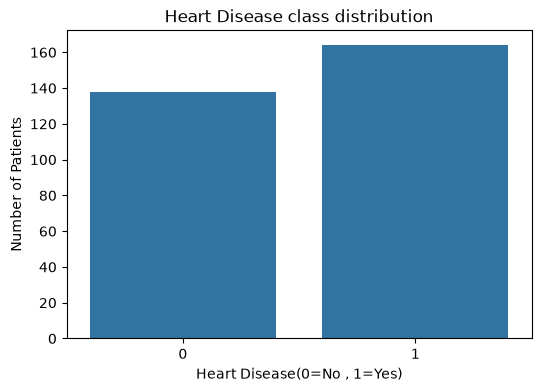

In [103]:
plt.figure(figsize=(6 , 4))
sns.countplot(data=df , x="target")
plt.title("Heart Disease class distribution")
plt.xlabel("Heart Disease(0=No , 1=Yes)")
plt.ylabel("Number of Patients")
plt.show()

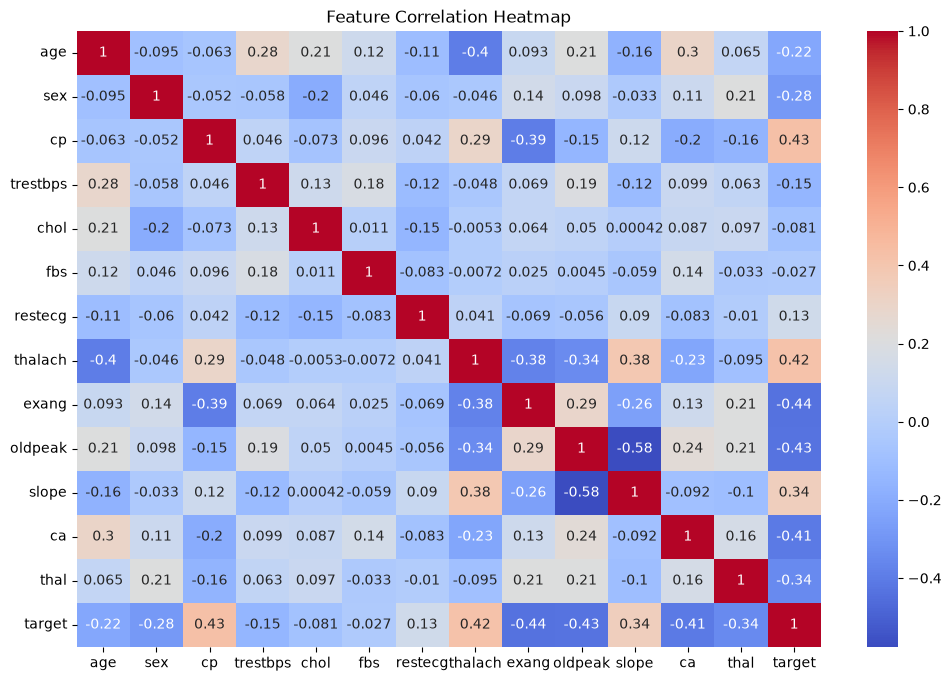

In [104]:
plt.figure(figsize=(12 , 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot = True,
    cmap ="coolwarm"
)
plt.title("Feature Correlation Heatmap")
plt.show()

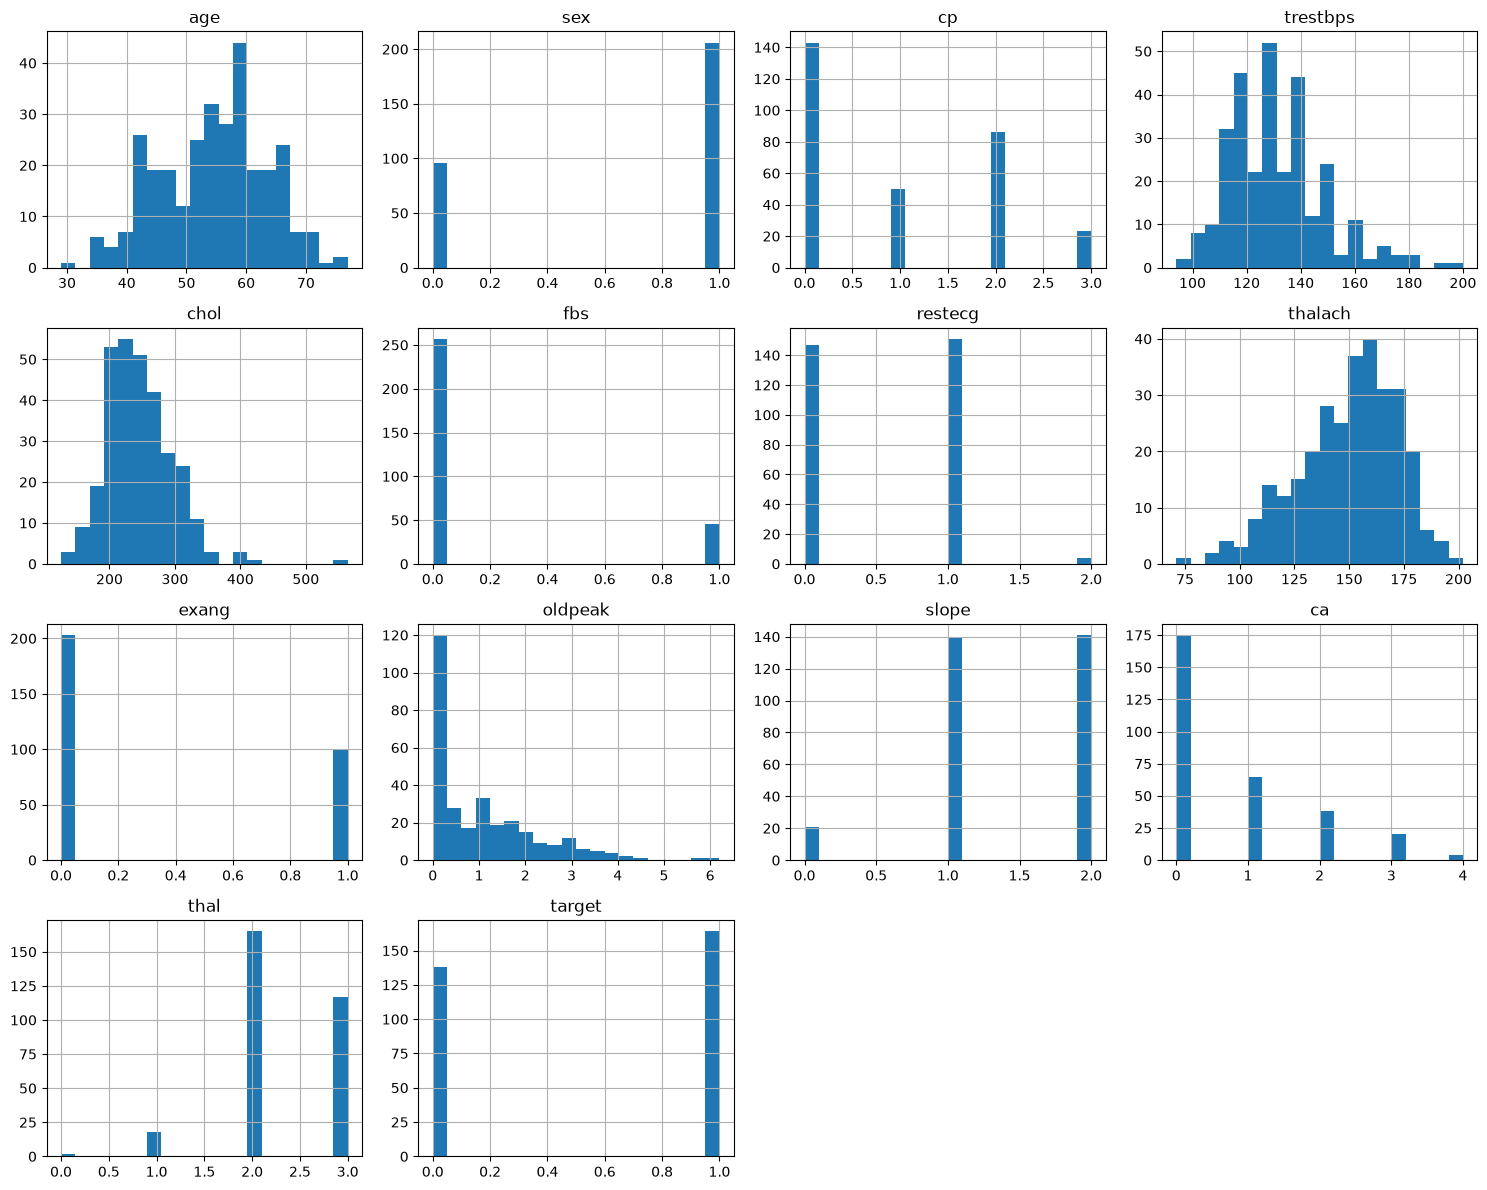

In [105]:
df.hist(
    figsize=(15 , 12),
    bins=20
)
plt.tight_layout()
plt.show()

## Preprocessing

In [106]:
X = df.drop("target" , axis=1)
y = df["target"]

In [107]:
from  sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size=0.2 , random_state=42 , stratify=y
)

In [108]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [109]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

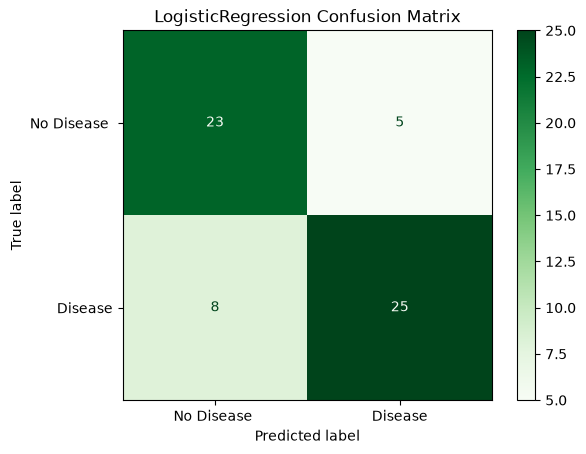

In [110]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test , y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease " , "Disease"]
)
disp.plot(cmap = "Greens")
plt.title("LogisticRegression Confusion Matrix")
plt.show()

In [111]:
logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

logistic_params = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"],
    "model__class_weight": [None, "balanced"]
}

In [112]:
dt = DecisionTreeClassifier(random_state=42)

dt_params = {
    "max_depth": [None, 3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": [None, "balanced"]
}

In [113]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    "n_estimators": [100, 200, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

In [114]:
gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [1, 2, 3, 5],
    "min_samples_split": [2, 5, 10]
}

In [115]:
ada = AdaBoostClassifier(random_state=42)

ada_params = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0]
}

In [116]:
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=42))
])

svm_params = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"],
    "model__class_weight": [None, "balanced"]
}

In [117]:
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_params = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

In [118]:
nb = GaussianNB()

nb_params = {
    "var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}

In [119]:
models = {
    "Logistic Regression": (logistic, logistic_params),
    "Decision Tree": (dt, dt_params),
    "Random Forest": (rf, rf_params),
    "Gradient Boosting": (gb, gb_params),
    "AdaBoost": (ada, ada_params),
    "SVM": (svm, svm_params),
    "KNN": (knn, knn_params),
    "Naive Bayes": (nb, nb_params)
}

In [120]:
from sklearn.metrics import recall_score

results = []

for name, (model, params) in models.items():

    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring="recall",
        cv=cv,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    results.append({
        "Model": name,
        "Best CV Recall": grid.best_score_,
        "Best Params": grid.best_params_
    })

    print(f"\n{name}")
    print("Best CV Recall:", grid.best_score_)
    print("Best Params:", grid.best_params_)


Logistic Regression
Best CV Recall: 0.9233618233618234
Best Params: {'model__C': 0.01, 'model__class_weight': None, 'model__solver': 'lbfgs'}

Decision Tree
Best CV Recall: 0.8321937321937323
Best Params: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Random Forest
Best CV Recall: 0.9082621082621083
Best Params: {'class_weight': None, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Gradient Boosting
Best CV Recall: 0.9156695156695157
Best Params: {'learning_rate': 0.01, 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 100}

AdaBoost
Best CV Recall: 0.9156695156695157
Best Params: {'learning_rate': 0.05, 'n_estimators': 50}


/home/akshay/Code/projects/heart-disease-pridiction/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/akshay/Code/projects/heart-disease-pridiction/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/akshay/Code/projects/heart-disease-pridiction/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/akshay/Code/projects/heart-disease


SVM
Best CV Recall: 1.0
Best Params: {'model__C': 0.01, 'model__class_weight': None, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

KNN
Best CV Recall: 0.9384615384615385
Best Params: {'model__n_neighbors': 21, 'model__p': 2, 'model__weights': 'uniform'}

Naive Bayes
Best CV Recall: 0.8623931623931623
Best Params: {'var_smoothing': 1e-11}


In [122]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

final_results = []

for name, (model, params) in models.items():

    grid = GridSearchCV(
        model,
        params,
        scoring="recall",
        cv=cv,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_prob = best_model.predict_proba(X_test)[:, 1]

    threshold = 0.40
    y_pred = (y_prob >= threshold).astype(int)

    if hasattr(best_model, "predict_proba"):
        y_prob = best_model.predict_proba(X_test)[:, 1]
    else:
        y_prob = best_model.decision_function(X_test)

    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    final_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "FN": fn,
        "FP": fp
    })

results_df = pd.DataFrame(final_results)

results_df.sort_values(
    by=["Recall", "FN"],
    ascending=[False, True]
)

/home/akshay/Code/projects/heart-disease-pridiction/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/akshay/Code/projects/heart-disease-pridiction/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/akshay/Code/projects/heart-disease-pridiction/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/akshay/Code/projects/heart-disease

,Model,Accuracy,Precision,Recall,F1,AUC,FN,FP
0,Logistic Regression,0.819672,0.775000,0.939394,0.849315,0.880952,2,9
6,KNN,0.803279,0.756098,0.939394,0.837838,0.889069,2,10
4,AdaBoost,0.786885,0.750000,0.909091,0.821918,0.860931,3,10
3,Gradient Boosting,0.737705,0.707317,0.878788,0.783784,0.840909,4,12
2,Random Forest,0.754098,0.736842,0.848485,0.788732,0.847403,5,10
1,Decision Tree,0.803279,0.818182,0.818182,0.818182,0.801948,6,6
7,Naive Bayes,0.803279,0.838710,0.787879,0.812500,0.884199,7,5
5,SVM,0.786885,0.857143,0.727273,0.786885,0.865801,9,4


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))